## 의사결정나무(DecisionTree)

### 1. 데이터 불러오기

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("../data/전처리완료.csv")

In [21]:
# 데이터 분리 라이브러리
from sklearn.model_selection import train_test_split

# 특징 변수(X)와 목표 변수(y) 분리
X = df.drop('고객이탈여부', axis=1)
y = df['고객이탈여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2. 모델 구현하기

#### 1) 예측하기

In [22]:
# 라이브러리 불러오기
from sklearn.tree import DecisionTreeClassifier

# 로지스틱 회귀 모델 학습
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 예측
y_pred = dt.predict(X_test)

y_pred

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

#### 2) 성능평가하기

In [23]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))


Accuracy: 0.782
Precision: 0.45274725274725275
Recall 0.5241730279898219
f1_score 0.4858490566037736


In [24]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[1358  249]
 [ 187  206]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1607
           1       0.45      0.52      0.49       393

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.80      0.78      0.79      2000



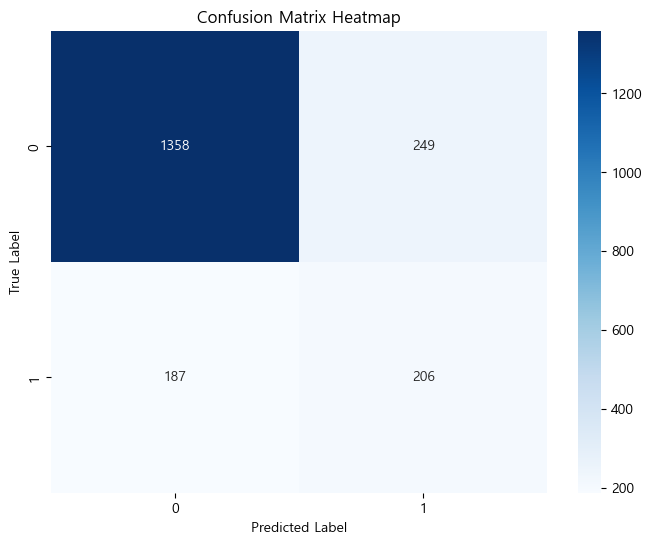

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### 3) 트리모형 구현하기

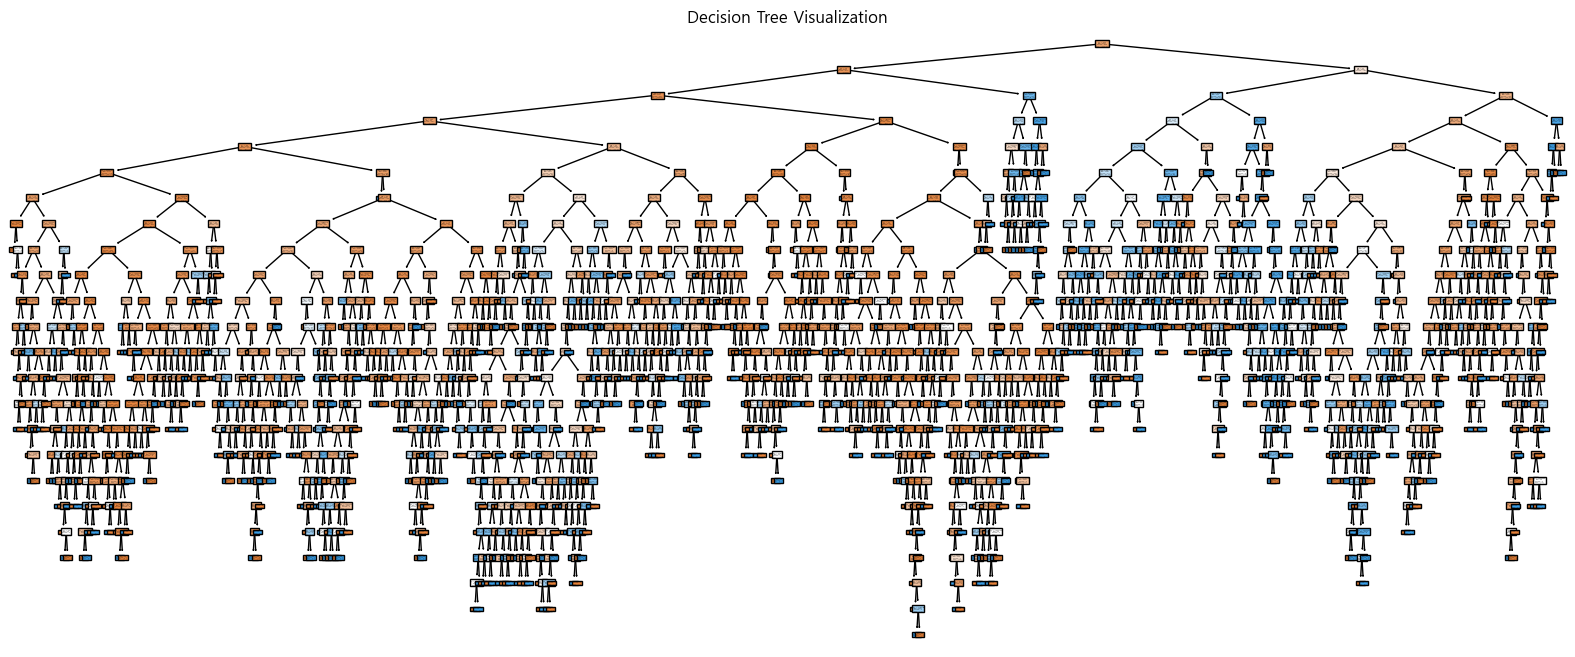

In [26]:
# pip install graphviz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 결정 트리 시각화
plt.figure(figsize=(20, 8))
plot_tree(dt, filled=True)
plt.title('Decision Tree Visualization')
plt.show()

#### 4) feature importance 구현

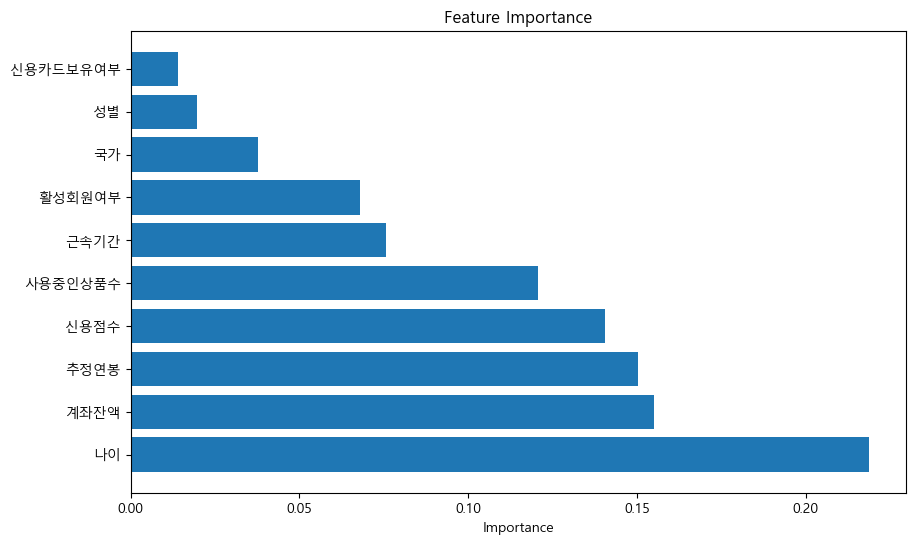

In [27]:
# 특성 중요도 계산
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
plt.title('Feature Importance')
plt.barh(range(X.shape[1]), importances[indices], align='center')
plt.yticks(range(X.shape[1]), np.array(X.columns)[indices])
plt.xlabel('Importance')
plt.show()

### 2. 하이퍼 파라미터 조정해보기

#### 1) 그리드 서치 CV

In [28]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier


# 하이퍼파라미터 그리드 정의
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [3, 4, 5, 6, 7],
    'max_features': ['auto', 'sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

# 그리드 서치 설정
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1)

# 그리드 서치 실행
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최고 정확도:", grid_search.best_score_)

# 테스트 데이터에 대한 평가
test_accuracy = grid_search.score(X_test, y_test)
print("테스트 데이터 정확도:", test_accuracy)

최적 하이퍼파라미터: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 5}
최고 정확도: 0.8543749999999999
테스트 데이터 정확도: 0.8575


c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
1000 fits failed out of a total of 4000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
587 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site

In [35]:
# 결정 트리 모델 생성 (주어진 하이퍼파라미터 적용)
dt = DecisionTreeClassifier(criterion='entropy', 
    max_depth=5, 
    max_features=None, 
    min_samples_leaf=2, 
    min_samples_split=2,
    random_state=42
)
# 모델 훈련
dt.fit(X_train, y_train)

# 예측
y_pred = dt.predict(X_test)

In [36]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8575
Precision: 0.7934782608695652
Recall 0.37150127226463103
f1_score 0.5060658578856153
Confusion Matrix:
 [[1569   38]
 [ 247  146]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92      1607
           1       0.79      0.37      0.51       393

    accuracy                           0.86      2000
   macro avg       0.83      0.67      0.71      2000
weighted avg       0.85      0.86      0.84      2000



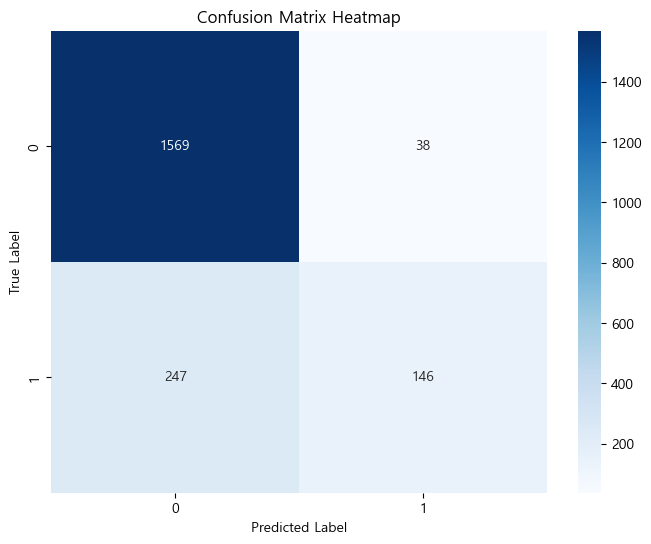

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

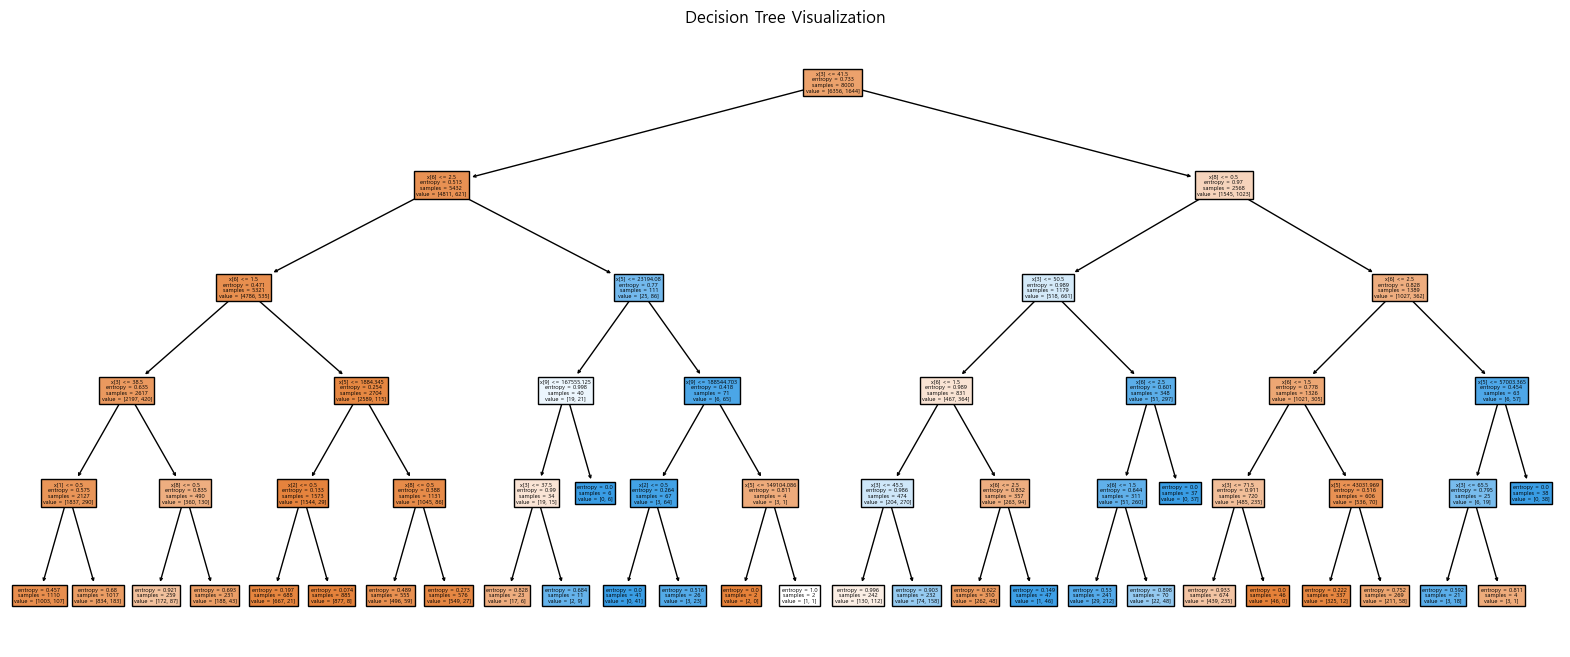

In [38]:
# 결정 트리 시각화
plt.figure(figsize=(20, 8))
plot_tree(dt, filled=True)
plt.title('Decision Tree Visualization')
plt.show()

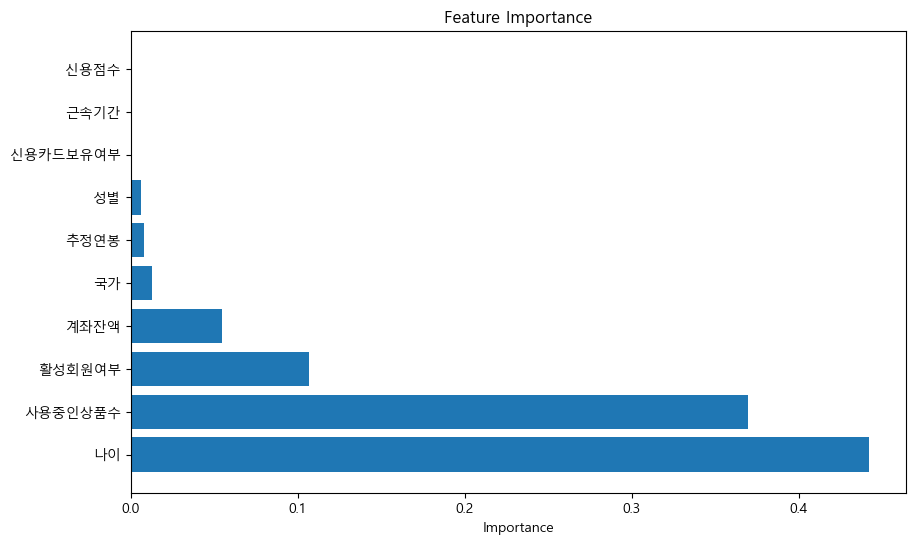

In [39]:
# 특성 중요도 계산
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
plt.title('Feature Importance')
plt.barh(range(X.shape[1]), importances[indices], align='center')
plt.yticks(range(X.shape[1]), np.array(X.columns)[indices])
plt.xlabel('Importance')
plt.show()

테스트 데이터 정확도: 0.8485


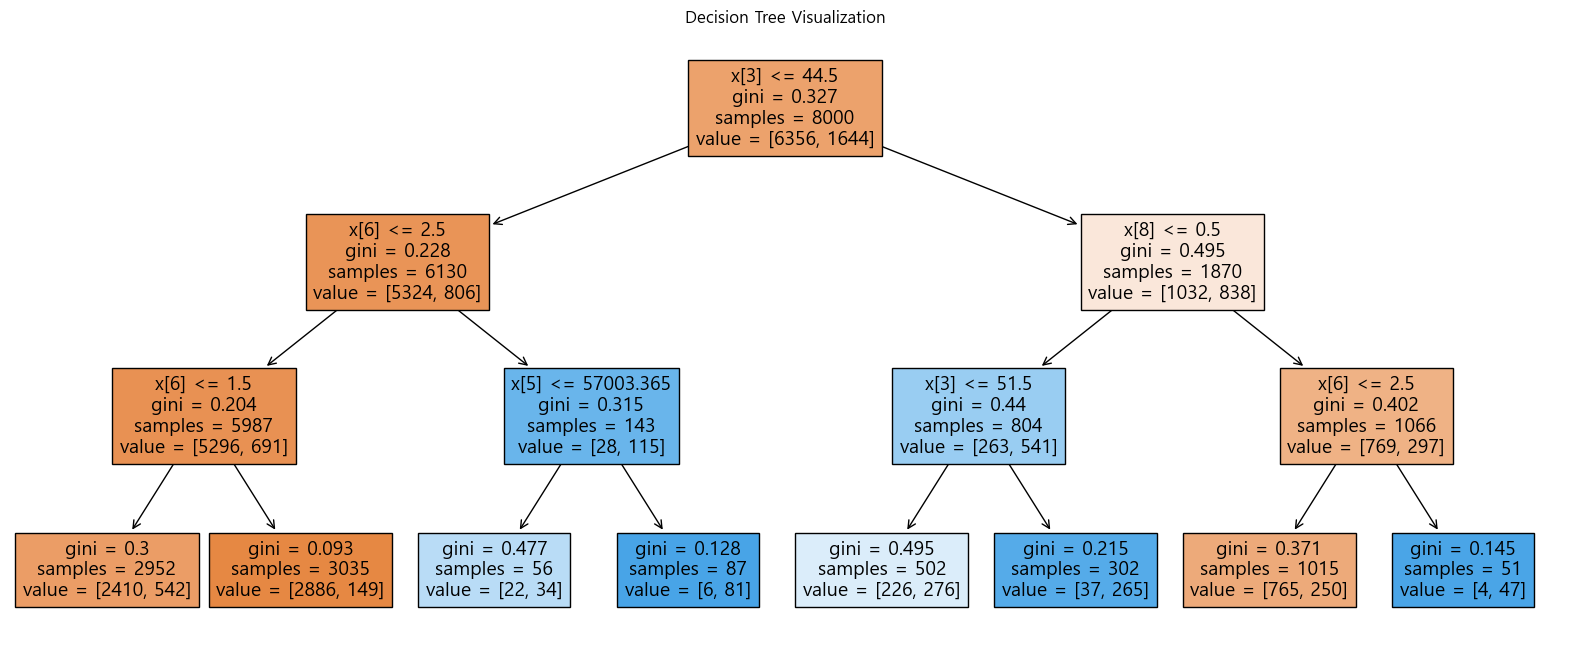

In [34]:

# 결정 트리 모델 생성 (주어진 하이퍼파라미터 적용)
dt = DecisionTreeClassifier( 
    max_depth=3, 
)

# 모델 훈련
dt.fit(X_train, y_train)


# 예측
y_pred = dt.predict(X_test)

# 테스트 데이터에 대한 정확도 평가
test_accuracy = dt.score(X_test, y_test)
print("테스트 데이터 정확도:", test_accuracy)

# 결정 트리 시각화
plt.figure(figsize=(20, 8))
plot_tree(dt, filled=True)
plt.title('Decision Tree Visualization')
plt.show()